In [1]:
!pip install pandas numpy matplotlib rouge

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [63]:
# Run this in a Jupyter cell to save the CSV
csv_content = '''Questions,Reference Answer,GraphRAG Answer,RAG Answer
"ആദിമ മനുഷ്യർ ഏതുതരം ഉപകരണങ്ങളാണ് കാട്ടുജന്തുക്കളിൽ നിന്നും രക്ഷനേടാൻ ഉപയോഗിച്ചിരുന്നത്?","ആദിമ മനുഷ്യർ കാട്ടുജന്തുക്കളിൽ നിന്നും രക്ഷനേടാൻ പ്രധാനമായും കല്ലുകൾ ഉപയോഗിച്ചുള്ള ഉപകരണങ്ങളാണ് ഉപയോഗിച്ചിരുന്നത്. അവർ കല്ലെറിയുകയും, പിന്നീട് കല്ലുകൊണ്ട് മഴു, കുന്തം തുടങ്ങിയ ഉപകരണങ്ങൾ ഉണ്ടാക്കാനും പഠിച്ചു.","ആദിമ മനുഷ്യർ കാട്ടുജന്തുക്കളിൽ നിന്നും രക്ഷനേടാൻ ഉരുളൻ കല്ല്, ദ്വിമുഖ മാതൃശില എന്നിവയും ഉപയോഗിച്ചിരുന്നു.","മഴയുടെ കാര്യം ഇവിടെ സൂചിപ്പിച്ചിട്ടുണ്ട്. 250 സെന്റിമീറ്റർ മുതൽ 400 സെന്റിമീറ്റർ വരെയാണ് ഈ കാലയളവിൽ പടിഞ്ഞാറൻ തീരത്തും പശ്ചിമഘട്ടത്തിന്റെ പടിഞ്ഞാറും ലഭിക്കുന്ന മഴ."
"പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ ഉപയോഗിച്ചിരുന്ന ഉപകരണങ്ങളുടെ പ്രധാന സവിശേഷത എന്തായിരുന്നു, എങ്ങനെയാണ് അവർ ആശയവിനിമയം നടത്തിയിരുന്നത്?","പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ ഉപയോഗിച്ചിരുന്ന ഉപകരണങ്ങളുടെ പ്രധാന സവിശേഷത അവ പരുക്കൻ കല്ലുകൾ കൊണ്ട് നിർമ്മിച്ചവയായിരുന്നു എന്നതാണ്. ആശയവിനിമയത്തിനായി അവർ ലളിതമായ ഒഴുക്കൻ വരകളും, കോറിയിട്ട ചിത്രങ്ങളും, ശില്പങ്ങളും ഉപയോഗിച്ചിരുന്നു. ഗുഹാഭിത്തികളിലെ ചിത്രീകരണങ്ങൾ, അസ്ഥികളിലെ കൊത്തുപണികൾ എന്നിവയും ആശയവിനിമയ മാർഗ്ഗങ്ങളായി കരുതപ്പെടുന്നു.","പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ ഉപയോഗിച്ചിരുന്ന ഉപകരണങ്ങളുടെ സവിശേഷത, അവ മുഖ്യമായും ശിലകൾ ഉപയോഗിച്ച് നിർമ്മിച്ചവയാണെന്നതാണ്. ഈ ശിലായുഗ ഉപകരണങ്ങൾ, ജീവിതത്തിന്റെ അടിസ്ഥാന ആവശ്യങ്ങൾ പൂർത്തിയാക്കാൻ ഉപയോഗിച്ചിരുന്നു, അവ ഭക്ഷണം ശേഖരിക്കുന്നതിനോ ഉപയോഗിക്കുന്നതിനോ, വേട്ടയാടൽ, ഭക്ഷണം തയ്യാറാക്കൽ എന്നിവയുൾപ്പെടെയുള്ള വിവിധ ജോലികൾക്ക് സഹായിച്ചു. ഈ പ്രാചീന മനുഷ്യർ ആശയവിനിമയം നടത്തിയിരുന്ന രീതികൾ, അവരുടെ ജീവിതത്തിലെ പ്രധാന മാറ്റങ്ങളും കണ്ടുപിടിത്തങ്ങളും പ്രതിഫലിപ്പിച്ചിരുന്നു, എന്നാൽ ഈ രീതികളെക്കുറിച്ച് വ്യക്തമായ രേഖപ്പെടുത്തലുകൾ ലഭ്യമല്ല.","പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ കല്ല്, മരം, ഹഡ്ഡി എന്നിവകൊണ്ട് നിർമ്മിച്ച ഉപകരണങ്ങൾ ഉപയോഗിച്ചിരുന്നു. ഈ ഉപകരണങ്ങൾ വേട്ടയാടൽ, ഭക്ഷണം തയ്യാറാക്കൽ, പ്രതിരോധം എന്നിവയ്ക്ക് ഉപയോഗിച്ചിരുന്നു. അവർ സംസാരിക്കുകയും ശബ്ദങ്ങൾ, ഇച്ഛാസിദ്ധാന്തങ്ങൾ എന്നിവ ഉപയോഗിച്ച് ആശയവിനിമയം നടത്തുകയും ചെയ്തിരുന്നു."
"നവീനശിലായുഗത്തിൽ മനുഷ്യജീവിതത്തിൽ വന്ന പ്രധാന മാറ്റങ്ങൾ എന്തൊക്കെയായിരുന്നു?","നവീനശിലായുഗത്തിൽ മനുഷ്യജീവിതത്തിൽ വിപ്ലവകരമായ മാറ്റങ്ങൾ സംഭവിച്ചു. അവയിൽ പ്രധാനപ്പെട്ടവ താഴെ പറയുന്നവയാണ്: കൃഷിയുടെ ആരംഭവും മൃഗങ്ങളെ ഇണക്കി വളർത്താൻ തുടങ്ങിയതും. മിനുസപ്പെടുത്തിയ ശിലാഉപകരണങ്ങൾ ഉപയോഗിക്കാൻ തുടങ്ങി, ഇത് കൃഷിക്ക് സഹായകമായി. കൃഷിയും കന്നുകാലി വളർത്തലും സ്ഥിരമായ ഭക്ഷ്യലഭ്യത ഉറപ്പാക്കിയതോടെ സ്ഥിരവാസവും കാർഷിക ഗ്രാമങ്ങളും രൂപപ്പെട്ടു. കളിമൺപാത്ര നിർമ്മാണവും ഇഷ്ടികയുടെ ഉപയോഗവും ആരംഭിച്ചു, ഇത് ധാന്യസംഭരണം സാധ്യമാക്കി. കാർഷിക രംഗത്തെ മിച്ചോത്പാദനം മറ്റു തൊഴിലുകളായ നെയ്ത്ത്, പാത്രനിർമ്മാണം എന്നിവയിൽ വൈദഗ്ദ്ധ്യം നേടുന്നതിലേക്ക് നയിച്ചു. സമൂഹത്തിൽ വിവിധ തൊഴിൽ വിഭാഗങ്ങൾ രൂപപ്പെട്ടു, ഇത് സാമൂഹിക ഘടനയിൽ മാറ്റങ്ങൾക്ക് തുടക്കം കുറിച്ചു. ഈ മാറ്റങ്ങളെ ""നവീനശിലായുഗ വിപ്ലവം"" എന്ന് ഗോർഡൻ ചൈൽഡ് വിശേഷിപ്പിക്കുന്നു. ","നവീനശിലായുഗം മനുഷ്യജീവിതത്തിൽ പ്രധാനപ്പെട്ട മാറ്റങ്ങൾ കൊണ്ടുവന്നു. ഈ കാലഘട്ടത്തിൽ, മനുഷ്യർ കൃഷി ചെയ്യാൻ തുടങ്ഞു, ഇത് ഭക്ഷ്യസമൃദ്ധിയിലേക്കും ജനസംഖ്യാ വർദ്ധനവിലേക്കും നയിച്ചു. കൃഷിയോടൊപ്പം, മനുഷ്യർ സ്ഥിരതാമസമാക്കാൻ തുടങ്ഞു, ഗ്രാമങ്ങളും പട്ടണങ്ങളും വികസിക്കാൻ തുടങ്ങി. ഈ സമൂഹങ്ങളിൽ, പ്രത്യേക ജോലികൾ നിലനിൽക്കാൻ തുടങ്ങി, വ്യക്തികൾ ഒരു പ്രത്യേക മേഖലയിൽ ശ്രദ്ധ കേന്ദ്രീകരിക്കാൻ തുടങ്ങി. സമൂഹത്തിലെ ഈ മാറ്റങ്ങൾ, വിഭിന്ന സാമൂഹിക ക്രമങ്ങൾക്കും സാംസ്കാരിക പ്രവർത്തനങ്ങൾക്കും വഴിയൊരുക്കി.","നവീനശിലായുഗത്തിൽ മനുഷ്യജീവിതത്തിൽ പ്രധാന മാറ്റങ്ങൾ ഉണ്ടായി. ഈ കാലഘട്ടത്തിൽ, ജനങ്ങൾ ഗോത്രസമൂഹങ്ങളായി ജീവിക്കാൻ തുടങ്ങി, അവർ കൃഷിയും പരമ്പരാഗത ഉൽപ്പന്നങ്ങളും ആശ്രയിക്കാൻ തുടങ്ങി. അവർ ഗ്രാമങ്ങളിലും നഗരങ്ങളിലും താമസിക്കാൻ തുടങ്ങി."
"അശോക ചക്രവർത്തി പ്രചരിപ്പിച്ച 'അശോകധമ്മ' എന്ന ആശയത്തിന്റെ പ്രധാന ലക്ഷ്യങ്ങളും തത്വങ്ങളും എന്തെല്ലാമായിരുന്നു?","അശോക ചക്രവർത്തി പ്രചരിപ്പിച്ച 'അശോകധമ്മ'യുടെ പ്രധാന ലക്ഷ്യം പ്രജകൾക്കിടയിൽ സഹവർത്തിത്വവും സമാധാനവും നിലനിർത്തുക എന്നതായിരുന്നു. അതിന്റെ പ്രധാന തത്വങ്ങൾ ഇവയായിരുന്നു: മറ്റ് മതവിശ്വാസങ്ങളോട് സഹിഷ്ണുത കാണിക്കുക. മുതിർന്നവരെയും ഗുരുക്കന്മാരെയും ബഹുമാനിക്കുക. അടിമകളോടും രോഗികളോടും ദയ കാണിക്കുക. ചരിത്രകാരിയായ റൊമിലഥാപ്പറുടെ അഭിപ്രായത്തിൽ, വിശാലമായ രാജ്യത്തിന്റെ കാര്യക്ഷമമായ ഭരണത്തിനും വിവിധ സാമൂഹിക വിഭാഗങ്ങളെ യോജിപ്പിച്ച് നിർത്തുന്നതിനും വേണ്ടിയുള്ള നയമായിരുന്നു അശോകധമ്മ. ","അശോക ചക്രവർത്തി പ്രചരിപ്പിച്ച 'അശോകധമ്മ' എന്ന ആശയത്തിന്റെ പ്രധാന ലക്ഷ്യങ്ങളും തത്വങ്ങളും ഇവയാണ്: 1. ദയകാണിക്കുന്ന അടിമകളോട് 2. ബഹുമാനിക്കുന്ന മുതിർന്നവരെ 3. പ്രോത്സാഹിപ്പിക്കുന്ന കച്ചവടത്തിന്റെ വളർച്ച 4. മറ്റ് മതവിശ്വാസികളോട് സഹിഷ്ണുത ഈ ആശയങ്ങൾ അനുസരിച്ച്, മറ്റ് മതവിശ്വാസികളോട് സഹിഷ്ണുത പുലർത്തുന്നതും മുതിർന്നവരെ ബഹുമാനിക്കുന്നതും അടിമകളോട് ദയ കാണിക്കുന്നതും ഉൾപ്പെടുന്നു. ഈ തത്വങ്ങൾ സമൂഹത്തെ ഏകീകരിക്കുന്നതിനും സാമൂഹിക സന്തോഷവും ശാന്തിയും പ്രോത്സാഹിപ്പിക്കുന്നതിനും ലക്ഷ്യമിട്ടുള്ളതാണ്.","അശോക ചക്രവർത്തി പ്രചരിപ്പിച്ച 'അശോകധമ്മ' എന്ന ആശയത്തിന്റെ പ്രധാന ലക്ഷ്യങ്ങളും തത്വങ്ങളും ഇവയായിരുന്നു: 1. മറ്റ് മതവിശ്വാസികളോട് സഹിഷ്ണുത പ്രദര്ശിപ്പിക്കുക, 2. മുതിർന്നവരെയും ഗുരുക്കന്മാരെയും ബഹുമാനിക്കുക, 3. അടിമകളോടും രോഗികളോടും ദയ കാണിക്കുക, 4. വിശാലമായ രാജ്യത്തിന്റെ കാര്യക്ഷമമായ ഭരണം, 5. വിവിധ സാമൂഹിക വിഭാഗങ്ങളെ ഐക്യപ്പെടുത്തൽ."
"ചോളന്മാരുടെയും ഡൽഹി സുൽത്താനേറ്റിന്റെയും ഭരണപരവും സാമ്പത്തികവുമായ വ്യവസ്ഥകളെ താരതമ്യം ചെയ്യാമോ?","ചോള ഭരണത്തിൽ രാജാവിന്റെ പേരിലുള്ള അളവുപാത്രം ഉപയോഗിച്ച് നെല്ലായും സ്വർണ്ണമായും കാശായും നികുതി പിരിച്ചിരുന്നു. കൃത്യമായ ഭൂമി അളക്കൽ സമ്പ്രദായം നിലനിന്നിരുന്നു. നാഗപട്ടണം, മഹാബലിപുരം തുടങ്ങിയ പ്രധാന വാണിജ്യ കേന്ദ്രങ്ങൾ ഉണ്ടായിരുന്നു. രാജാവിനെ സഹായിക്കാൻ മന്ത്രിമാരുടെ സമിതിയും ശക്തമായ സൈന്യവും (നാവികസേന ഉൾപ്പെടെ) ഉണ്ടായിരുന്നു. രാജ്യത്തെ മണ്ഡലങ്ങൾ, വളനാടുകൾ, നാടുകൾ എന്നിങ്ങനെ വിഭജിച്ചിരുന്നു. മറുവശത്ത്, ഡൽഹി സുൽത്താനേറ്റിൽ ഇൽത്തുമിഷ് നടപ്പിലാക്കിയ 'ഇഖ്ത' സമ്പ്രദായം നിലനിന്നിരുന്നു. ഇതിലൂടെ രാജ്യത്തെ ഭൂപ്രദേശങ്ങൾ സൈനികർക്കും ഉദ്യോഗസ്ഥർക്കും പ്രഭുക്കന്മാർക്കും വീതിച്ചുനൽകി. അലാവുദ്ദീൻ ഖൽജി കമ്പോള നിയന്ത്രണം നടപ്പിലാക്കി, ഭക്ഷ്യസാധനങ്ങൾ ഉൾപ്പെടെയുള്ളവയുടെ വില നിയന്ത്രിച്ചു. ടാങ്ക് (വെള്ളി), ദിർഹം (ചെമ്പ്) നാണയങ്ങളെ അടിസ്ഥാനമാക്കിയുള്ള പണവ്യവസ്ഥ വ്യാപാരത്തെ പ്രോത്സാഹിപ്പിച്ചു. കയറ്റുമതിയും ഇറക്കുമതിയും ശക്തമായിരുന്നു. നികുതി പണമായി പിരിച്ചത് പണ സമ്പദ്‌വ്യവസ്ഥയ്ക്ക് കാരണമായി.","ഇല്ല, ഈ ഭരണപരവും സാമ്പത്തികവുമായ വ്യവസ്ഥകളെ താരതമ്യം ചെയ്യാന് കഴിയില്ല.","ഇല്ല, അത് സാധ്യമല്ല."
"രാഷ്ട്രകൂട, ഡൽഹി സുൽത്താനേറ്റ് കാലഘട്ടങ്ങളിലെ സാമൂഹിക യാഥാർത്ഥ്യങ്ങളെ, സമത്വം ഉറപ്പാക്കുന്നതിനും വിവേചനം തടയുന്നതിനുമുള്ള ഭരണഘടനാപരമായ നിർദ്ദേശങ്ങളുമായി താരതമ്യം ചെയ്യാമോ?","രാഷ്ട്രകൂടരുടെ ഭരണകാലത്ത് സമൂഹം ജാതി അടിസ്ഥാനത്തിൽ കൂടുതൽ വിഭജിക്കപ്പെട്ടു. ചാതുർവർണ്യത്തിന് പുറമേ പലതരം വിവേചനങ്ങളും അയിത്തവും നിലനിന്നിരുന്നു. വാണിജ്യത്തിന്റെ തകർച്ച വൈശ്യരുടെ പദവിക്ക് കോട്ടം വരുത്തിയപ്പോൾ, കൃഷിയുടെ പുരോഗതിയും സൈന്യത്തിലെ അംഗത്വവും ശൂദ്രരുടെ സ്ഥിതി മെച്ചപ്പെടുത്തി. ഡൽഹി സുൽത്താനേറ്റ് കാലഘട്ടത്തിലും സമൂഹത്തിൽ നിരവധി അസമത്വങ്ങൾ നിലനിന്നു. സുൽത്താൻ, പ്രഭുക്കന്മാർ, ഗ്രാമത്തലവൻമാർ എന്നിവർ ഉയർന്ന ജീവിതം നയിച്ചപ്പോൾ ഭൂരിഭാഗം ജനങ്ങളും യാതനകൾ അനുഭവിച്ചു. ജാതിവ്യവസ്ഥ അടിസ്ഥാനപരമായി മാറിയില്ല. എന്നാൽ, ആധുനിക ഇന്ത്യൻ ഭരണഘടന (അദ്ധ്യായം 7, 8) സമത്വം (അനുച്ഛേദം 14), സാമൂഹിക നീതി, ലിംഗഭേദത്തിന്റെ അടിസ്ഥാനത്തിലുള്ള വിവേചനമില്ലായ്മ (അനുച്ഛേദം 15), അവസരസമത്വം (അനുച്ഛേദം 16) എന്നിവ ഉറപ്പുനൽകുന്നു. ഭരണഘടന ഒരു ന്യായസമൂഹമാണ് വിഭാവനം ചെയ്യുന്നത്. ദേശീയ മനുഷ്യാവകാശ കമ്മീഷൻ, പട്ടികജാതി-പട്ടികവർഗ്ഗ കമ്മീഷനുകൾ തുടങ്ങിയ സ്ഥാപനങ്ങൾ ഈ ഭരണഘടനാ മൂല്യങ്ങൾ നടപ്പിലാക്കാൻ ശ്രമിക്കുന്നു. ഇത് ചരിത്രപരമായ അസമത്വങ്ങളെ അഭിമുഖീകരിക്കുന്നു. ","ഇല്ല, ഈ കാലഘട്ടത്തിലെ സാമൂഹിക യാഥാർത്ഥ്യങ്ങളും ഭരണഘടനാപരമായ നിർദ്ദേശങ്ങളും തമ്മിൽ വ്യത്യസ്തമാണ്. ഭരണകാലത്ത് ജാതി, അന്തരിഷ്ട വിഭാഗീയം എന്നിങ്ങനെ സമൂഹം കൂടുതൽ വിഭജിക്കപ്പെട്ടു. ഈ ഘട്ടത്തിൽ മരപ്പണിക്കാർ, ചെരുപ്പ്‌ നിർമ്മാതാക്കൾ, മീൻപിടിത്തക്കാർ തുടങ്ങിയ വിഭാഗങ്ങൾക്ക് വിവേചനവും അയിത്തവും ഏറ്റുട്ടുണ്ടായിരുന്നു. എന്നാൽ ഭരണഘടനാപരമായ നിർദ്ദേശങ്ങൾ സമത്വം ഉറപ്പാക്കുന്നതിനും വിവേചനം തടയുന്നതിനുമുള്ള നിബന്ധനകൾ അടങ്ങിയിരിക്കുന്നു.","ഇല്ല, ഈ കാലഘട്ടങ്ങളിലെ സാമൂഹിക യാഥാർത്ഥ്യങ്ങളും ഭരണഘടനാപരമായ നിർദ്ദേശങ്ങളും തമ്മിൽ സാമ്യമില്ല."
"ആധുനിക തിരഞ്ഞെടുപ്പ് കമ്മീഷന്റെ പങ്കുകളും പ്രവർത്തനങ്ങളും, ചോളന്മാരുടേയോ ഡൽഹി സുൽത്താനേറ്റിന്റെയോ പോലുള്ള വലിയ ഭരണപ്രദേശങ്ങൾ സ്ഥാപിക്കുന്നതിനും പരിപാലിക്കുന്നതിനും ചരിത്രപരമായി നേരിട്ടിരുന്ന വെല്ലുവിളികളെ എങ്ങനെയാണ് അഭിമുഖീകരിക്കുന്നത്?","ചോളന്മാരും ഡൽഹി സുൽത്താന്മാരും ഭരണം സ്ഥാപിച്ചത് പ്രധാനമായും സൈനിക ശക്തിയിലൂടെയും പിന്തുടർച്ചാവകാശത്തിലൂടെയുമാണ്. വലിയ സാമ്രാജ്യങ്ങൾ ഭരിക്കാൻ അവർ ഭരണപരമായ വിഭജനങ്ങൾ (മണ്ഡലം, നാട്, ഇഖ്ത) ഉപയോഗിച്ചു. എന്നാൽ ആധുനിക ജനാധിപത്യത്തിൽ, തിരഞ്ഞെടുപ്പ് കമ്മീഷൻ നീതിപൂർവവും നിഷ്പക്ഷവുമായ തിരഞ്ഞെടുപ്പുകളിലൂടെയാണ് ജനപ്രതിനിധികളെയും ഭരണാധികാരികളെയും അധികാരത്തിലെത്തിക്കുന്നത്. വോട്ടർ പട്ടിക തയ്യാറാക്കൽ, തിരഞ്ഞെടുപ്പ് മേൽനോട്ടം, പെരുമാറ്റച്ചട്ടം നടപ്പിലാക്കൽ, രാഷ്ട്രീയപ്പാർട്ടികൾക്ക് അംഗീകാരം നൽകൽ തുടങ്ങിയ ചുമതലകളിലൂടെ കമ്മീഷൻ, വിപുലവും സങ്കീർണ്ണവുമായ ഇന്ത്യൻ ജനാധിപത്യ സംവിധാനത്തിൽ ജനപങ്കാളിത്തം ഉറപ്പാക്കുന്നു. ഇത് ചരിത്രത്തിലെ രാജവാഴ്ച/സൈനിക ഭരണ രീതികളിൽ നിന്ന് വ്യത്യസ്തമായി, ഭരണത്തിന് ജനാധിപത്യപരമായ സാധുത നൽകുന്നു. സാർവത്രിക പ്രായപൂർത്തി വോട്ടവകാശം നടപ്പിലാക്കുന്നതിലൂടെ, വലിയതും വൈവിധ്യപൂർണ്ണവുമായ ജനവിഭാഗത്തിന് ഭരണത്തിൽ പങ്കാളികളാകാൻ അവസരം ലഭിക്കുന്നു, ഇത് പഴയകാല ഭരണരീതികളിൽ നിന്ന് വ്യത്യസ്തമാണ്. ","ആധുനിക തിരഞ്ഞെടുപ്പ് കമ്മീഷന്റെ പങ്കും പ്രവർത്തനങ്ങളും, ചരിത്രപരമായി നേരിട്ടിരുന്ന വെല്ലുവിളികൾ, അതായത് ചോളന്മാരുടേയോ ഡൽഹി സുൽത്താനേറ്റിന്റെയോ പോലുള്ള വലിയ ഭരണപ്രദേശങ്ങൾ സ്ഥാപിക്കുന്നതിനും പരിപാലിക്കുന്നതിനുമുള്ള വെല്ലുവിളികൾ, അവ പരിഹരിക്കുന്നതിന് സമീപനങ്ങൾ ഉണ്ടാക്കും. ഒരു ജനാധിപത്യ സമീപനം നടപ്പിലാക്കുന്നതിന്, അവരുടെ ഘടനകൾക്കുള്ളിൽ പാർപ്പിക്കുകയോ പുനഃസംഘടിപ്പിക്കുകയോ ചെയ്ത്, പൗരന്മാരുടെ അവകാശങ്ങൾക്ക് പ്രാധാന്യം നൽകാം. ഭരണപരമായ കാര്യക്ഷമതയും ഫലപ്രാപ്തിയും ഉറപ്പുവരുത്തുന്നതിന്, കമ്മീഷൻ ദീർഘകാല തന്ത്രങ്ങൾ ആവിഷ്കരിക്കാൻ ശ്രമിക്കും. ഇത്, പൗരന്മാരുടെ പങ്കാളിത്തവും സഹകരണവും ശക്തിപ്പെടുത്തുന്നതിലൂടെ, മികച്ച ജനാധിപത്യ ഭരണം നടപ്പിലാക്കുന്നതിന് സഹായിക്കും.","ചരിത്രപരമായി, വലിയ ഭരണപ്രദേശങ്ങൾ സ്ഥാപിക്കുന്നതും പരിപാലിക്കുന്നതും വെല്ലുവിളിയാണ്. എന്നാൽ, ഈ വെല്ലുവിളികൾ അഭിമുഖീകരിക്കുന്നതിൽ ആധുനിക തിരഞ്ഞെടുപ്പ് കമ്മീഷന് ഒരു പങ്കുണ്ട്."
"ദക്ഷിണേന്ത്യയിലെ വിവിധ രാജവംശങ്ങൾ  ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ നൽകിയ സംഭാവനകൾ താരതമ്യം ചെയ്യുക.ഉദാഹരണമായി Chola dynasty എന്നും Chalukya dynasty എന്നും എടുത്ത് വിശദീകരിക്കുക.","ദക്ഷിണേന്ത്യയിലെ വിവിധ രാജവംശങ്ങൾ ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ വലിയ പങ്കുവഹിച്ചു. അതിൽ പ്രധാനമായത് ചോള രാജവംശവും  ചാളുക്യരാജവംശവും ആണ്.ചോളരാജവംശത്തിന്റെ കാലത്ത് ദ്രാവിഡ ശൈലിയിലുള്ള ക്ഷേത്രവാസ്തുവിദ്യ വളരെ വികസിച്ചു. അവർ വലിയ കല്ലുകൊണ്ടുള്ള ക്ഷേത്രങ്ങളും ഉയർന്ന വിമാനം (ഗോപുരം) ഉള്ള ഭംഗിയുള്ള ക്ഷേത്രങ്ങളും നിർമ്മിച്ചു. ഈ കാലഘട്ടത്തിൽ ശില്പകലയും വെങ്കലവിഗ്രഹങ്ങളും ഏറെ പുരോഗതി നേടി. ഇതിന്റെ മികച്ച ഉദാഹരണമാണ് ബ്രഹ്ദീശ്വര ക്ഷേത്രം.ചാളുക്യരാജവംശത്തിന്റെ കാലത്ത് ക്ഷേത്രവാസ്തുവിദ്യയിൽ നാഗരയും ദ്രാവിഡ ശൈലിയും സംയോജിപ്പിച്ച ഒരു പുതിയ ശൈലി വികസിച്ചു. അവർ പാറക്കല്ലിൽ കൊത്തിയ ഗുഹാക്ഷേത്രങ്ങളും കെട്ടിടക്ഷേത്രങ്ങളും നിർമ്മിക്കുകയും ശില്പാലങ്കാരങ്ങളിൽ കൂടുതൽ ശ്രദ്ധ നൽകുകയും ചെയ്തു. ഇതിന് ഉദാഹരണങ്ങളാണ് വിരുപക്ഷ ക്ഷേത്രവും ബദാമി ഗുഹാക്ഷേത്രങ്ങളും.അങ്ങനെ ചോളരും ചാളുക്യരും തങ്ങളുടെ വ്യത്യസ്തമായ ശൈലികളിലൂടെ ദക്ഷിണേന്ത്യയിലെ ക്ഷേത്ര ശില്പകലയുടെ വളർച്ചയിൽ വലിയ സംഭാവനകൾ നൽകി.","ദക്ഷിണേന്ത്യയിലെ വിവിധ രാജവംശങ്ങൾ ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ വളരെയധികം സംഭാവനകൾ നൽകിയിട്ടുണ്ട്. ചോള രാജവംശവും ചാലൂക്യ രാജവംശവും ഇതിൽ പ്രധാനപ്പെട്ട രണ്ട് രാജവംശങ്ങളാണ്.ചോള രാജവംശം തമിഴ്നാട്ടിലെ തഞ്ചാവൂരിൽ സ്ഥാപിതമായിരുന്നു. അവർ ബ്രഹ്ദീശ്വര ക്ഷേത്രം പോലെയുള്ള വലിയ ക്ഷേത്രങ്ങൾ നിർമ്മിച്ചു, ഇത് ഇന്ന് യുനെസ്കോയുടെ ലോക പൈതൃക സ്ഥലമാണ്. ചോള രാജവംശം ശില്പകലയിലും ചിത്രകലയിലും വളരെയധികം സംഭാവനകൾ നൽകിയിട്ടുണ്ട്.ചാലൂക്യ രാജവംശം കർണ്ണാടകയിലെ ബാദാമിയിൽ സ്ഥാപിതമായിരുന്നു. അവർ ബാദാമി ക്ഷേത്രങ്ങൾ പോലെയുള്ള വലിയ ക്ഷേത്രങ്ങൾ നിർമ്മിച്ചു, ഇത് ഇന്ന് യുനെസ്കോയുടെ ലോക പൈതൃക സ്ഥലമാണ്. ചാലൂക്യ രാജവംശം ശില്പകലയിലും വാസ്തുവിദ്യയിലും വളരെയധികം സംഭാവനകൾ നൽകിയിട്ടുണ്ട്.ഈ രണ്ട് രാജവംശങ്ങളും ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ വളരെയധികം സംഭാവനകൾ നൽകിയിട്ടുണ്ട്. എന്നിരുന്നാലും, ചോള രാജവംശം ശില്പകലയിലും ചിത്രകലയിലും കൂടുതൽ ശ്രദ്ധ കേന്ദ്രീകരിച്ചപ്പോൾ, ചാലൂക്യ രാജവംശം വാസ്തുവിദ്യയിലും ശില്പകലയിലും കൂടുതൽ ശ്രദ്ധ കേന്ദ്രീകരിച്ചു.","ഈ വിവരങ്ങളിൽ ദക്ഷിണേന്ത്യയിലെ വിവിധ രാജവംശങ്ങൾ ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ നൽകിയ സംഭാവനകളെക്കുറിച്ച് പൂർണ്ണമായ താരതമ്യം ചെയ്യാനുള്ള വിവരങ്ങൾ ലഭ്യമല്ല. പ്രത്യേകിച്ച്, ചോദ്യത്തിൽ ഉദാഹരണമായി നൽകിയിട്ടുള്ള ചോള (Chola) രാജവംശത്തെക്കുറിച്ചോ ചാലൂക്യ (Chalukya) രാജവംശത്തെക്കുറിച്ചോ ക്ഷേത്ര ശില്പകലയുമായി ബന്ധപ്പെട്ട വിവരങ്ങൾ ഈ രേഖകളിൽ ലഭ്യമല്ല.എന്നിരുന്നാലും, ദക്ഷിണേന്ത്യയിലെ ക്ഷേത്ര ശില്പകലയുടെ വികാസത്തെക്കുറിച്ച് ലഭ്യമായ വിവരങ്ങൾ താഴെ നൽകുന്നു:പല്ലവരും പാണ്ഡ്യരും ശൈവ-വൈഷ്ണവ ക്ഷേത്രങ്ങൾ നിർമ്മിക്കുകയും ഭക്തി പ്രസ്ഥാനത്തെ പ്രോത്സാഹിപ്പിക്കുകയും ചെയ്തു എന്ന് പേജ് 60-ൽ പറയുന്നു.ദക്ഷിണേന്ത്യൻ ക്ഷേത്രങ്ങൾ അക്കാലത്തെ ജനജീവിതത്തിൽ കാര്യമായ സ്വാധീനം ചെലുത്തിയിരുന്നു എന്നും ക്ഷേത്രങ്ങൾ അക്കാലത്തെ പ്രധാന കലാ നിർമ്മിതികളായിരുന്നു എന്നും പേജ് 60-ൽ സൂചിപ്പിക്കുന്നു.കാഞ്ചീപുരം, മഹാബലിപുരം, മധുര എന്നിവിടങ്ങളിലാണ് അക്കാലത്തെ പ്രധാന ക്ഷേത്രങ്ങൾ സ്ഥിതിചെയ്യുന്നത് എന്ന് പേജ് 60-ൽ പറയുന്നു.'ദ്രാവിഡശൈലി' എന്ന ദക്ഷിണേന്ത്യൻ ക്ഷേത്രനിർമ്മാണശൈലി പല്ലവരുടെ കാലത്താണ് രൂപപ്പെട്ടത് എന്ന് പേജ് 60-ൽ വ്യക്തമാക്കുന്നു.കാലക്രമേണ ക്ഷേത്രനിർമ്മാണം മൂന്നുഘട്ടങ്ങളിലായി വികാസം പ്രാപിച്ചു എന്നും അവ പാറവെട്ടി നിർമ്മിച്ച ക്ഷേത്രങ്ങൾ, ഒറ്റക്കല്ലിൽ തീർത്ത രഥക്ഷേത്രങ്ങൾ, ഘടനാ ക്ഷേത്രങ്ങൾ എന്നിവയാണെന്നും പേജ് 60-ൽ വിവരിക്കുന്നു.ചോദ്യത്തിൽ ആവശ്യപ്പെട്ടതുപോലെ ചോള രാജവംശത്തെക്കുറിച്ചോ ചാലൂക്യ രാജവംശത്തെക്കുറിച്ചോ ക്ഷേത്ര ശില്പകലയുടെ വികസനത്തിൽ അവർ നൽകിയ സംഭാവനകളെക്കുറിച്ച് ഈ വിവരങ്ങളിൽ പരാമർശമില്ല. പേജ് 46-ൽ ചോളന്മാരെ ഒരു രാജവംശമായി പരാമർശിക്കുന്നുണ്ടെങ്കിലും, അവരുടെ വാസ്തുവിദ്യാ സംഭാവനകളെക്കുറിച്ച് വിവരങ്ങളൊന്നും നൽകിയിട്ടില്ല. ചാലൂക്യ രാജവംശത്തെക്കുറിച്ച് ഈ വിവരങ്ങളിൽ ഒരിടത്തും പരാമർശമില്ല. അതിനാൽ, ഈ വിവരങ്ങൾ ഉപയോഗിച്ച് ചോദ്യത്തിന് പൂർണ്ണമായി ഉത്തരം നൽകാൻ കഴിയില്ല."
"ശിലായുഗത്തെ എങ്ങനെയെല്ലാം തരം തിരിക്കാം ?","ശിലായുഗത്തെ കല്ലുപകരണങ്ങളുടെ നിർമാണരീതിയെ അടിസ്ഥാനമാക്കി മൂന്ന് ഘട്ടങ്ങളായി തരംതിരിക്കുന്നു.ശിലായുഗത്തിന്റെ വിഭാഗങ്ങൾ:പ്രാചീന ശിലായുഗം,മധ്യ ശിലായുഗം, നവീന ശിലായുഗം ","ശിലായുഗത്തെ പ്രാചീനശിലായുഗം, മധ്യശിലായുഗം, നവീനശിലായുഗം എന്നിങ്ങനെ മൂന്നായി തരംതിരിക്കാം.","ശിലായുഗത്തെ കല്ലുകൾകൊണ്ടുള്ള ഉപകരണങ്ങളുടെ നിർമ്മാണരീതിയെ അടിസ്ഥാനമാക്കി മൂന്നായി തരം തിരിക്കാം:പ്രാചീനശിലായുഗം (Palaeolithic Age),മധ്യശിലായുഗം (Mesolithic Age),നവീനശിലായുഗം (Neolithic Age)"
"സുപ്രീം കോടതിയുടെ അധികാരങ്ങൾ എന്തെല്ലാം ആണ് ?","സുപ്രീംകോടതിയുടെ പ്രധാന അധികാരങ്ങൾ ഇവയാണ്:പ്രാരംഭാധികാരം: കേന്ദ്രവും സംസ്ഥാനങ്ങളും തമ്മിലോ, സംസ്ഥാനങ്ങൾ തമ്മിലോ ഉള്ള തർക്കങ്ങൾ നേരിട്ട് പരിഗണിക്കുന്നു.അപ്പീൽ അധികാരം: ഹൈക്കോടതി വിധികൾക്കെതിരെയുള്ള അപ്പീലുകൾ കേൾക്കുന്നു.ഉപദേശക അധികാരം: പ്രധാനപ്പെട്ട നിയമപ്രശ്നങ്ങളിൽ രാഷ്ട്രപതിക്ക് ഉപദേശം നൽകുന്നു.റിട്ട് അധികാരം: പൗരന്മാരുടെ മൗലികാവകാശങ്ങൾ സംരക്ഷിക്കുന്നതിനായി റിട്ടുകൾ പുറപ്പെടുവിക്കുന്നു.","സുപ്രീം കോടതിയുടെ അധികാരങ്ങൾ വൈവിധ്യമാർന്നതാണ്. ഇന്ത്യൻ ഭരണഘടനയുടെ പാര്ട്ട് ഫൈവിലെ ആർട്ടിക്കിൾ 124 മുതൽ 147 വരെയുള്ള വകുപ്പുകൾ സുപ്രീം കോടതിയുടെ ഘടന, അധികാരങ്ങൾ, പ്രവർത്തനങ്ങൾ എന്നിവയെക്കുറിച്ചാണ് സംസാരിക്കുന്നത്. സുപ്രീം കോടതിയ്ക്ക് അപ്പീൽ അധികാരം, മൂലധന അധികാരം, സമീപന അധികാരം തുടങ്ങിയ വിവിധ അധികാരങ്ങൾ ഉണ്ട്. കൂടാതെ, ഭരണഘടനാ വിവാദങ്ങൾ പരിഹരിക്കുന്നതിനുള്ള അധികാരവും സുപ്രീം കോടതിയ്ക്കുണ്ട്.","സുപ്രീംകോടതിയുടെ അധികാരങ്ങൾ താഴെ പറയുന്നവയാണ്:ഉത്ഭവാധികാരം:  സുപ്രീംകോടതിക്ക് മാത്രം പരിഹരിക്കാൻ കഴിയുന്ന ചില വിഷയങ്ങളാണ് ഇതിന്റെ പരിധിയിൽ വരുന്നത്. ഉദാഹരണം - കേന്ദ്രസംസ്ഥാന തർക്കങ്ങൾ.അപ്പീൽ പരിഗണിക്കാനുള്ള അധികാരം: സുപ്രീംകോടതി ഏറ്റവും ഉയർന്ന അപ്പീൽ കോടതിയാണ്. രാജ്യത്തെ ഏതൊരു കീഴ്ക്കോടതിയുടെയും വിധിയിന്മേൽ വരുന്ന അപ്പീലുകൾ സ്വീകരിക്കാനുള്ള അധികാരം സുപ്രീംകോടതിക്കുണ്ട്.ഉപദേശക അധികാരം: രാഷ്ട്രപതി ആവശ്യപ്പെടുന്ന ഏതൊരു വിഷയത്തെ സംബന്ധിച്ചും നിയമോപദേശം നൽകുവാൻ സുപ്രീംകോടതിക്ക് ഭരണഘടനാപരമായ ബാധ്യതയുണ്ട്.റിട്ട്‌ അധികാരം:മൗലികാവകാശങ്ങൾ ലംഘിക്കപ്പെടുമ്പോൾ അവയുടെ സംരക്ഷണാർത്ഥം റിട്ടുകളുടെ രൂപത്തിൽ പ്രത്യേക ഉത്തരവുകൾ പുറപ്പെടുവിക്കാൻ സുപ്രീംകോടതിക്ക് അധികാരമുണ്ട്.പുനരവലോകന അധികാരം (നീതിന്യായ പുനരവലോകനം): പാർലമെന്റ് പാസാക്കുന്ന നിയമങ്ങളുടെയും കാര്യനിർവഹണ വിഭാഗം പുറപ്പെടുവിക്കുന്ന ഉത്തരവുകളുടെയും ഭരണഘടനാസാധുത പരിശോധിക്കുവാനും അവ ഭരണഘടനയുടെ വാക്കുകൾക്കോ അർത്ഥത്തിനോ വിരുദ്ധമാണെന്ന് ബോധ്യമായാൽ അവയെ ഭരണഘടനാവിരുദ്ധമെന്ന് പ്രഖ്യാപിക്കുവാനുമുള്ള സുപ്രീംകോടതിയുടെ പ്രത്യേക അധികാരമാണിത്."
'''

with open('evaluation_fixed.csv', 'w', encoding='utf-8') as f:
    f.write(csv_content)

print("✅ evaluation_fixed.csv created with 10 QA pairs")

# Verify
import pandas as pd
df = pd.read_csv('evaluation_fixed.csv', encoding='utf-8')
print(f"Total QA pairs: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

✅ evaluation_fixed.csv created with 10 QA pairs
Total QA pairs: 10
Columns: ['Questions', 'Reference Answer', 'GraphRAG Answer', 'RAG Answer']


In [64]:
df = pd.read_csv(
    "evaluation_fixed.csv",
    encoding="utf-8",
    engine="python",
    quotechar='"',
    sep=",",
    on_bad_lines="skip"
)

In [66]:
# Initialize Rouge calculator
rouge = Rouge()

# Lists to store individual scores
graphrag_scores = []
rag_scores = []

# Calculate ROUGE scores for each row
for index, row in df.iterrows():
    reference = row['Reference Answer']
    graphrag_answer = row['GraphRAG Answer']
    rag_answer = row['RAG Answer']
    
    # Skip invalid entries (empty answers)
    if not isinstance(reference, str) or not isinstance(graphrag_answer, str) or not isinstance(rag_answer, str):
        continue
    
    if len(reference.strip()) == 0 or len(graphrag_answer.strip()) == 0 or len(rag_answer.strip()) == 0:
        continue
    
    try:
        # Calculate scores for GraphRAG
        graphrag_score = rouge.get_scores(graphrag_answer, reference)[0]
        graphrag_scores.append(graphrag_score)
        
        # Calculate scores for RAG
        rag_score = rouge.get_scores(rag_answer, reference)[0]
        rag_scores.append(rag_score)
    except Exception as e:
        print(f"Error calculating scores for row {index}: {e}")

In [67]:
def calculate_average_scores(scores_list):
    if not scores_list:
        return None
    
    # Initialize dictionaries to store sums
    rouge1_sum = {'f': 0, 'p': 0, 'r': 0}
    rouge2_sum = {'f': 0, 'p': 0, 'r': 0}
    rougeL_sum = {'f': 0, 'p': 0, 'r': 0}
    
    # Sum up all scores
    for score in scores_list:
        for metric in ['f', 'p', 'r']:
            rouge1_sum[metric] += score['rouge-1'][metric]
            rouge2_sum[metric] += score['rouge-2'][metric]
            rougeL_sum[metric] += score['rouge-l'][metric]
    
    # Calculate averages
    n = len(scores_list)
    avg_scores = {
        'rouge-1': {metric: value/n for metric, value in rouge1_sum.items()},
        'rouge-2': {metric: value/n for metric, value in rouge2_sum.items()},
        'rouge-l': {metric: value/n for metric, value in rougeL_sum.items()}
    }
    
    return avg_scores

# Calculate average scores
avg_graphrag_scores = calculate_average_scores(graphrag_scores)
avg_rag_scores = calculate_average_scores(rag_scores)

# Print comparison
print("\nAverage ROUGE Scores Comparison:")
print("\nGraphRAG scores:")
for rouge_type in ['rouge-1', 'rouge-2', 'rouge-l']:
    print(f"  {rouge_type}: F1={avg_graphrag_scores[rouge_type]['f']:.4f}, Precision={avg_graphrag_scores[rouge_type]['p']:.4f}, Recall={avg_graphrag_scores[rouge_type]['r']:.4f}")

print("\nRAG scores:")
for rouge_type in ['rouge-1', 'rouge-2', 'rouge-l']:
    print(f"  {rouge_type}: F1={avg_rag_scores[rouge_type]['f']:.4f}, Precision={avg_rag_scores[rouge_type]['p']:.4f}, Recall={avg_rag_scores[rouge_type]['r']:.4f}")

# Calculate and print the differences
print("\nDifference (GraphRAG - RAG):")
for rouge_type in ['rouge-1', 'rouge-2', 'rouge-l']:
    f1_diff = avg_graphrag_scores[rouge_type]['f'] - avg_rag_scores[rouge_type]['f']
    p_diff = avg_graphrag_scores[rouge_type]['p'] - avg_rag_scores[rouge_type]['p']
    r_diff = avg_graphrag_scores[rouge_type]['r'] - avg_rag_scores[rouge_type]['r']
    
    print(f"  {rouge_type}: F1={f1_diff:.4f}, Precision={p_diff:.4f}, Recall={r_diff:.4f}")


Average ROUGE Scores Comparison:

GraphRAG scores:
  rouge-1: F1=0.1592, Precision=0.2010, Recall=0.1393
  rouge-2: F1=0.0555, Precision=0.0686, Recall=0.0506
  rouge-l: F1=0.1575, Precision=0.1981, Recall=0.1381

RAG scores:
  rouge-1: F1=0.1328, Precision=0.1804, Recall=0.1309
  rouge-2: F1=0.0411, Precision=0.0454, Recall=0.0407
  rouge-l: F1=0.1328, Precision=0.1804, Recall=0.1309

Difference (GraphRAG - RAG):
  rouge-1: F1=0.0263, Precision=0.0205, Recall=0.0083
  rouge-2: F1=0.0144, Precision=0.0232, Recall=0.0099
  rouge-l: F1=0.0247, Precision=0.0177, Recall=0.0072


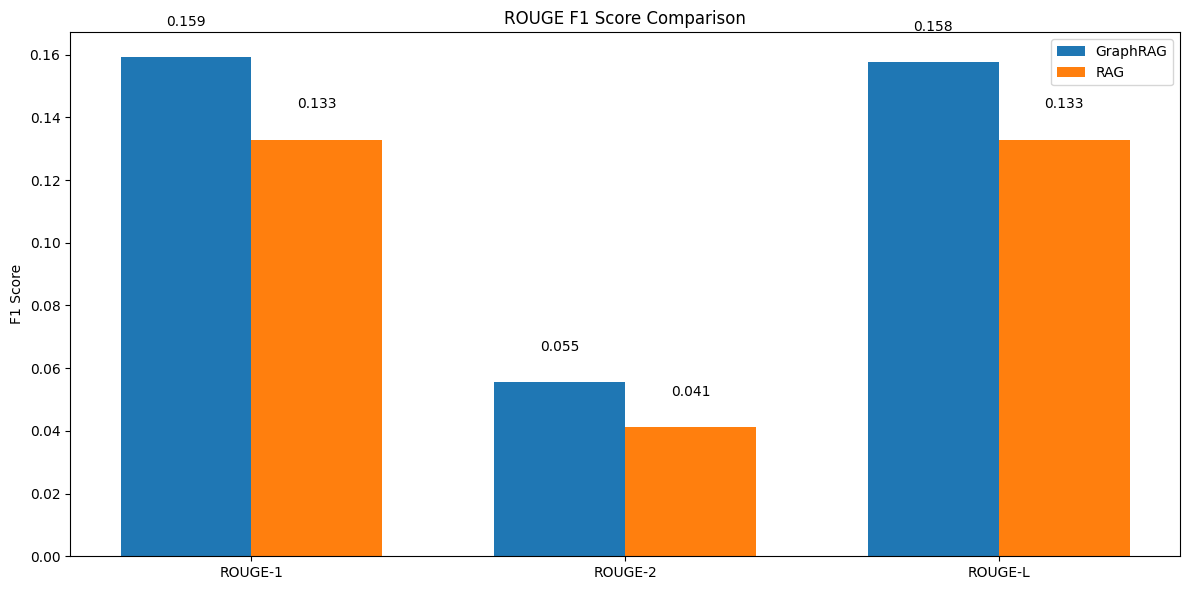

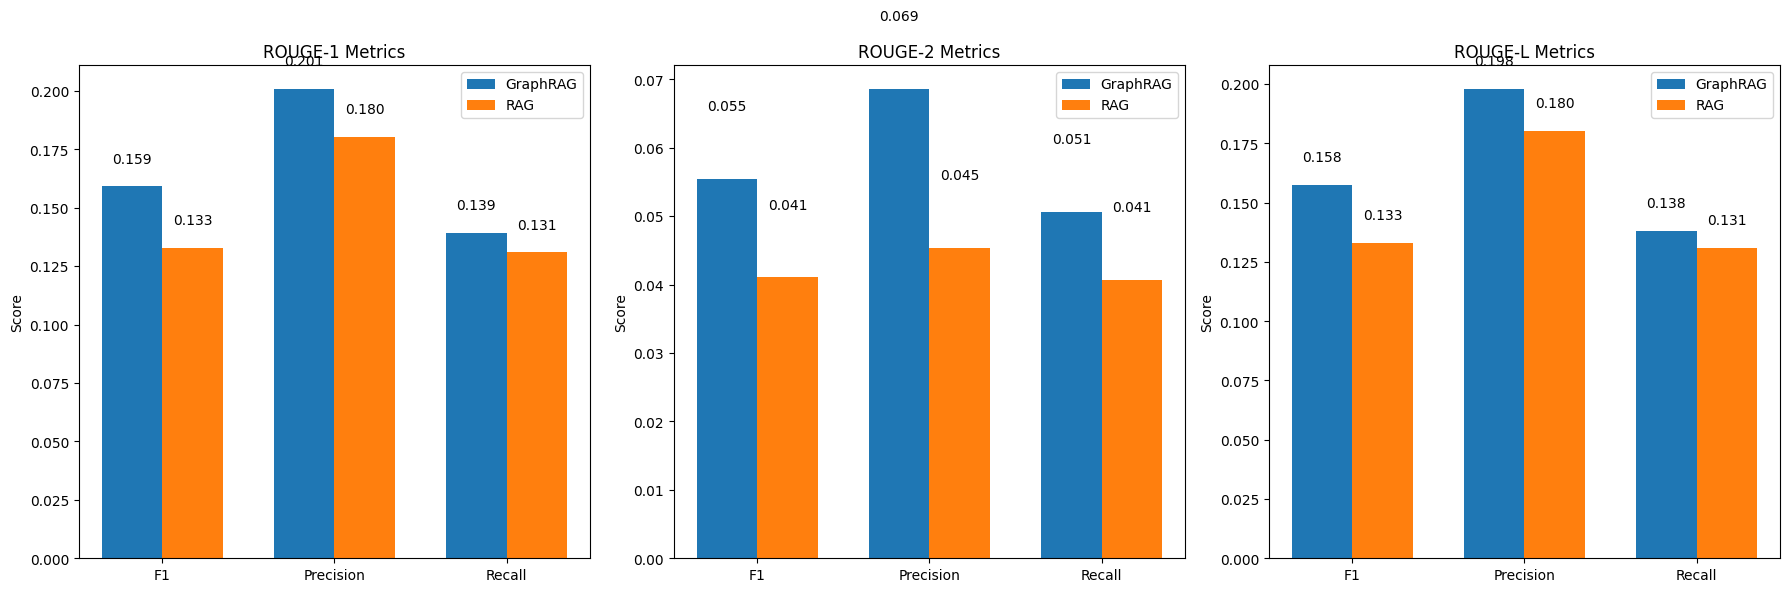

In [68]:


import matplotlib.pyplot as plt
import numpy as np

# Create bar chart comparison
def create_comparison_charts(graphrag_scores, rag_scores):
    metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    graphrag_f1 = [graphrag_scores['rouge-1']['f'], graphrag_scores['rouge-2']['f'], graphrag_scores['rouge-l']['f']]
    rag_f1 = [rag_scores['rouge-1']['f'], rag_scores['rouge-2']['f'], rag_scores['rouge-l']['f']]
    
    # F1 Score Comparison
    plt.figure(figsize=(12, 6))
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, graphrag_f1, width, label='GraphRAG')
    plt.bar(x + width/2, rag_f1, width, label='RAG')
    
    plt.ylabel('F1 Score')
    plt.title('ROUGE F1 Score Comparison')
    plt.xticks(x, metrics)
    plt.legend()
    
    # Add values on top of bars
    for i, v in enumerate(graphrag_f1):
        plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')
    
    for i, v in enumerate(rag_f1):
        plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig('rouge_comparison.png')
    plt.show()
    
    # Create a more detailed comparison with all metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # For each ROUGE metric
    for i, rouge_type in enumerate(['rouge-1', 'rouge-2', 'rouge-l']):
        metrics = ['F1', 'Precision', 'Recall']
        graphrag_values = [graphrag_scores[rouge_type]['f'], 
                         graphrag_scores[rouge_type]['p'], 
                         graphrag_scores[rouge_type]['r']]
        rag_values = [rag_scores[rouge_type]['f'], 
                    rag_scores[rouge_type]['p'], 
                    rag_scores[rouge_type]['r']]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        axes[i].bar(x - width/2, graphrag_values, width, label='GraphRAG')
        axes[i].bar(x + width/2, rag_values, width, label='RAG')
        
        axes[i].set_ylabel('Score')
        axes[i].set_title(f'ROUGE-{rouge_type[-1].upper() if rouge_type[-1] != "l" else "L"} Metrics')
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(metrics)
        axes[i].legend()
        
        # Add values on top of bars
        for j, v in enumerate(graphrag_values):
            axes[i].text(j - width/2, v + 0.01, f'{v:.3f}', ha='center')
        
        for j, v in enumerate(rag_values):
            axes[i].text(j + width/2, v + 0.01, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig('rouge_detailed_comparison.png')
    plt.show()

# This function would be called after calculating the average scores
create_comparison_charts(avg_graphrag_scores, avg_rag_scores)



In [8]:


!pip install pandas nltk sacrebleu



Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     |████████████████████████████████| 104 kB 2.5 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [71]:
import pandas as pd
import csv

# Read the CSV file properly handling multiline fields
with open('evaluation_fixed.csv', 'r', encoding='utf-8') as f:
    # Read the entire content
    content = f.read()

# Split by the pattern of new question (starts with quote)
import re
pattern = r'("[^"]+",".*?",".*?",".*?")'
matches = re.findall(pattern, content, re.DOTALL)

print(f"Found {len(matches)} QA pairs")

# Parse each match properly
data = []
for match in matches:
    # Parse CSV line
    reader = csv.reader([match], quotechar='"', delimiter=',', quoting=csv.QUOTE_ALL)
    for row in reader:
        if len(row) == 4:
            data.append(row)

# Create DataFrame
df = pd.DataFrame(data, columns=['Questions', 'Reference Answer', 'GraphRAG Answer', 'RAG Answer'])
print(f"✅ Total QA pairs: {len(df)}")
print("\nFirst 2 questions:")
for i in range(min(2, len(df))):
    print(f"\n{i+1}. {df.iloc[i]['Questions'][:50]}...")

Found 10 QA pairs
✅ Total QA pairs: 10

First 2 questions:

1. ആദിമ മനുഷ്യർ ഏതുതരം ഉപകരണങ്ങളാണ് കാട്ടുജന്തുക്കളിൽ...

2. പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ ഉപയോഗിച്ചിരുന്ന ഉപകര...


In [72]:
def preprocess_text(text):
    """Clean and tokenize Malayalam text"""
    if pd.isna(text):
        return []
    # Basic cleaning
    text = str(text).strip()
    # Tokenize by spaces (you might need more sophisticated Malayalam tokenization)
    tokens = text.split()
    return tokens

# Preprocess all answers
ref_tokens = [preprocess_text(ans) for ans in reference_answers]
graphrag_tokens = [preprocess_text(ans) for ans in graphrag_answers]
rag_tokens = [preprocess_text(ans) for ans in rag_answers]


In [73]:
# Convert back to strings for SacreBLEU
ref_strings = [' '.join(tokens) for tokens in ref_tokens]
graphrag_strings = [' '.join(tokens) for tokens in graphrag_tokens]
rag_strings = [' '.join(tokens) for tokens in rag_tokens]

bleu = BLEU()

# Calculate BLEU scores
graphrag_bleu = bleu.corpus_score(graphrag_strings, [ref_strings])
rag_bleu = bleu.corpus_score(rag_strings, [ref_strings])

In [74]:
import pandas as pd
import numpy as np
from sacrebleu import BLEU

# Load dataset
df = pd.read_csv(
    "evaluationSet.csv",
    encoding="utf-8",
    engine="python",
    quoting=3,
    on_bad_lines="skip"
)

reference_answers = df['Reference Answer'].astype(str).tolist()
graphrag_answers = df['GraphRAG Answer'].astype(str).tolist()
rag_answers = df['RAG Answer'].astype(str).tolist()

bleu = BLEU()

# Store sentence BLEU scores
graphrag_bleu_scores = []
rag_bleu_scores = []

for ref, g_ans, r_ans in zip(reference_answers, graphrag_answers, rag_answers):

    g_score = bleu.sentence_score(g_ans, [ref]).score
    r_score = bleu.sentence_score(r_ans, [ref]).score

    graphrag_bleu_scores.append(g_score)
    rag_bleu_scores.append(r_score)

# Corpus BLEU (overall score)
graphrag_corpus_bleu = bleu.corpus_score(graphrag_answers, [reference_answers])
rag_corpus_bleu = bleu.corpus_score(rag_answers, [reference_answers])

print("GraphRAG Corpus BLEU:", graphrag_corpus_bleu.score)
print("RAG Corpus BLEU:", rag_corpus_bleu.score)

# Average sentence BLEU
avg_graphrag_bleu = np.mean(graphrag_bleu_scores)
avg_rag_bleu = np.mean(rag_bleu_scores)

print(f"Average GraphRAG BLEU Score: {avg_graphrag_bleu:.4f}")
print(f"Average RAG BLEU Score: {avg_rag_bleu:.4f}")
print(f"Difference: {avg_graphrag_bleu - avg_rag_bleu:.4f}")

# Add to dataframe
df['GraphRAG_BLEU'] = graphrag_bleu_scores
df['RAG_BLEU'] = rag_bleu_scores
df['BLEU_Difference'] = df['GraphRAG_BLEU'] - df['RAG_BLEU']

# Save results
df.to_csv("results_with_bleu_scores.csv", index=False)

print("Results saved to results_with_bleu_scores.csv")

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is 

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is 

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is 

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.
It is 

GraphRAG Corpus BLEU: 0.5951608004892036
RAG Corpus BLEU: 0.7545087022152189
Average GraphRAG BLEU Score: 0.1398
Average RAG BLEU Score: 0.1858
Difference: -0.0461
Results saved to results_with_bleu_scores.csv


In [75]:
import pandas as pd
import numpy as np
from sacrebleu import BLEU

In [78]:
import pandas as pd
import csv

# Read the CSV file properly handling multiline fields
with open('evaluation_fixed.csv', 'r', encoding='utf-8') as f:
    # Read the entire content
    content = f.read()

# Split by the pattern of new question (starts with quote)
import re
pattern = r'("[^"]+",".*?",".*?",".*?")'
matches = re.findall(pattern, content, re.DOTALL)

print(f"Found {len(matches)} QA pairs")

# Parse each match properly
data = []
for match in matches:
    # Parse CSV line
    reader = csv.reader([match], quotechar='"', delimiter=',', quoting=csv.QUOTE_ALL)
    for row in reader:
        if len(row) == 4:
            data.append(row)

# Create DataFrame
df = pd.DataFrame(data, columns=['Questions', 'Reference Answer', 'GraphRAG Answer', 'RAG Answer'])
print(f"✅ Total QA pairs: {len(df)}")
print("\nFirst 2 questions:")
for i in range(min(2, len(df))):
    print(f"\n{i+1}. {df.iloc[i]['Questions'][:50]}...")

Found 10 QA pairs
✅ Total QA pairs: 10

First 2 questions:

1. ആദിമ മനുഷ്യർ ഏതുതരം ഉപകരണങ്ങളാണ് കാട്ടുജന്തുക്കളിൽ...

2. പ്രാചീന ശിലായുഗത്തിലെ മനുഷ്യർ ഉപയോഗിച്ചിരുന്ന ഉപകര...


In [79]:
reference_answers = df['Reference Answer'].astype(str).tolist()
graphrag_answers = df['GraphRAG Answer'].astype(str).tolist()
rag_answers = df['RAG Answer'].astype(str).tolist()

In [80]:
graphrag_bleu_scores = []
rag_bleu_scores = []

bleu = BLEU(effective_order=True)

for ref, g_ans, r_ans in zip(reference_answers, graphrag_answers, rag_answers):

    g_score = bleu.sentence_score(g_ans, [ref]).score
    r_score = bleu.sentence_score(r_ans, [ref]).score

    graphrag_bleu_scores.append(g_score)
    rag_bleu_scores.append(r_score)

In [81]:
graphrag_corpus_bleu = bleu.corpus_score(graphrag_answers, [reference_answers])
rag_corpus_bleu = bleu.corpus_score(rag_answers, [reference_answers])

print("GraphRAG Corpus BLEU:", graphrag_corpus_bleu.score)
print("RAG Corpus BLEU:", rag_corpus_bleu.score)

GraphRAG Corpus BLEU: 3.536426004451648
RAG Corpus BLEU: 3.7272607531846615


In [82]:
avg_graphrag_bleu = np.mean(graphrag_bleu_scores)
avg_rag_bleu = np.mean(rag_bleu_scores)

print(f"Average GraphRAG BLEU Score: {avg_graphrag_bleu:.4f}")
print(f"Average RAG BLEU Score: {avg_rag_bleu:.4f}")
print(f"Difference: {avg_graphrag_bleu - avg_rag_bleu:.4f}")

Average GraphRAG BLEU Score: 4.1760
Average RAG BLEU Score: 3.9434
Difference: 0.2326


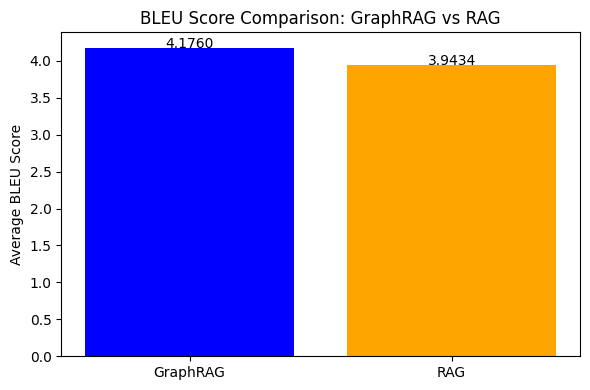

In [92]:
import matplotlib.pyplot as plt

# Values
models = ['GraphRAG', 'RAG']
bleu_scores = [avg_graphrag_bleu, avg_rag_bleu]

# Colors for each model
colors = ['blue', 'orange']   # GraphRAG = blue, RAG = orange

plt.figure(figsize=(6,4))
plt.bar(models, bleu_scores, color=colors)

plt.ylabel('Average BLEU Score')
plt.title('BLEU Score Comparison: GraphRAG vs RAG')

# Show score values on bars
for i, v in enumerate(bleu_scores):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()